In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor

In [2]:
df = pd.read_csv('student_performance.csv')
df['family_support'] = df['family_support'].map({'yes': 1, 'no': 0})
df['pass_fail'] = (df['G3'] >= 10).astype(int)
features_columns = ['family_support', 'study_time', 'failures', 'G1', 'G2', 'G3', 'pass_fail']
df = df[features_columns]
df

,family_support,study_time,failures,G1,G2,G3,pass_fail
0,0,2,2,5,7,3.1,0
1,0,3,3,5,12,7.2,0
2,0,1,1,17,14,16.4,1
3,0,1,3,9,17,12.4,1
4,1,1,3,8,16,9.8,0
...,...,...,...,...,...,...,...
995,0,1,0,7,17,14.2,1
996,0,2,2,7,17,11.0,1
997,0,1,0,9,14,13.5,1
998,0,3,1,15,6,11.1,1


In [4]:
x_features = ['family_support', 'study_time', 'failures', 'G1', 'G2']
X = df[x_features].values
y = df['pass_fail'].values
y

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Gini impurity

$$ GINI = 1- \sum_{i=0}^{k} p_i^2 $$

In [6]:
def gini_impurity(y):
    p1 = np.sum(y) / len(y)
    p0 = 1 - p1
    return 1 - p1**2 - p0**2

In [19]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [20]:
y_hat = dt.predict(X_test)
accuracy_score(y_test, y_hat)

0.84

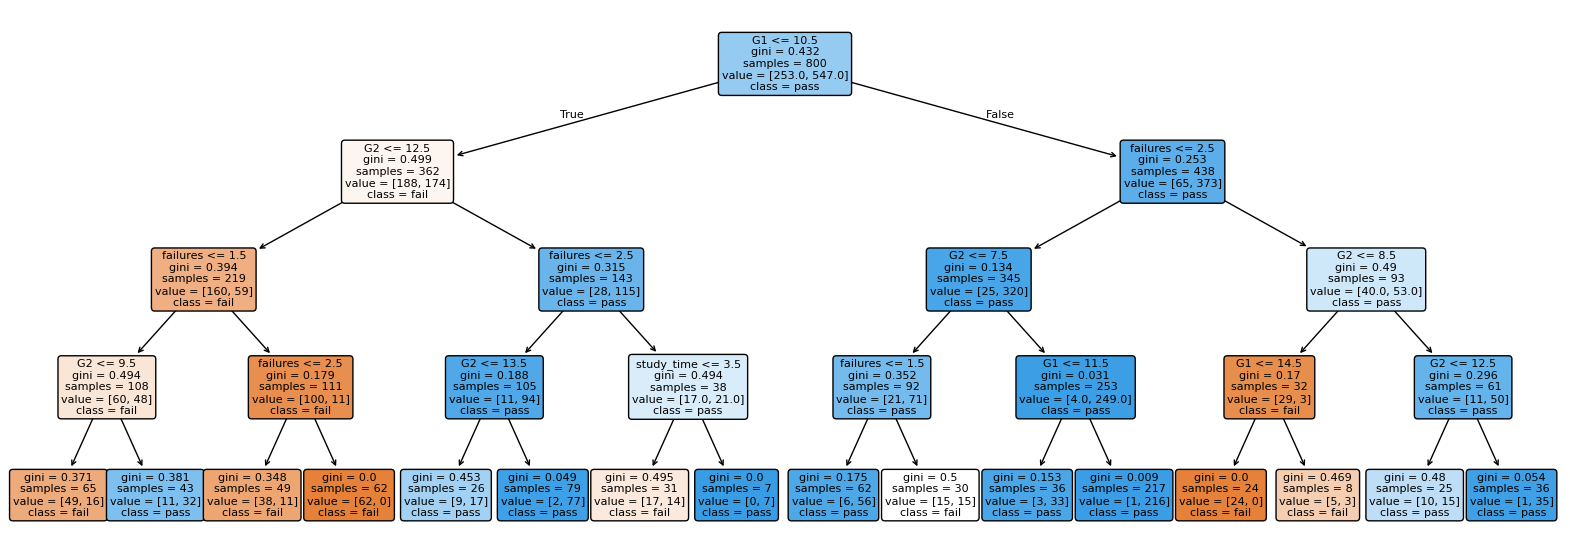

In [22]:
plt.figure(figsize=(20, 7))
plot_tree(dt, feature_names=x_features, class_names=['fail', 'pass'], fontsize=8, rounded=True, filled=True)
plt.show()

In [24]:
# --- Test depths in a loop ---
depths = range(1, 21)  # test depth 1 to 20
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = dt.score(X_train, y_train)
    test_acc  = dt.score(X_test, y_test)
    
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Depth {depth:2d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")





Depth  1 | Train Acc: 0.7013 | Test Acc: 0.6550
Depth  2 | Train Acc: 0.8100 | Test Acc: 0.7600
Depth  3 | Train Acc: 0.8425 | Test Acc: 0.7850
Depth  4 | Train Acc: 0.8725 | Test Acc: 0.8400
Depth  5 | Train Acc: 0.9075 | Test Acc: 0.8550
Depth  6 | Train Acc: 0.9300 | Test Acc: 0.8650
Depth  7 | Train Acc: 0.9513 | Test Acc: 0.8500
Depth  8 | Train Acc: 0.9725 | Test Acc: 0.8350
Depth  9 | Train Acc: 0.9825 | Test Acc: 0.8550
Depth 10 | Train Acc: 0.9875 | Test Acc: 0.8550
Depth 11 | Train Acc: 0.9888 | Test Acc: 0.8400
Depth 12 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 13 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 14 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 15 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 16 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 17 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 18 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 19 | Train Acc: 0.9900 | Test Acc: 0.8400
Depth 20 | Train Acc: 0.9900 | Test Acc: 0.8400


In [25]:
# --- Find best depth ---
best_depth = depths[np.argmax(test_accs)]
best_acc   = max(test_accs)
print(f"\n✅ Best depth: {best_depth} with Test Accuracy: {best_acc:.4f}")


✅ Best depth: 6 with Test Accuracy: 0.8650


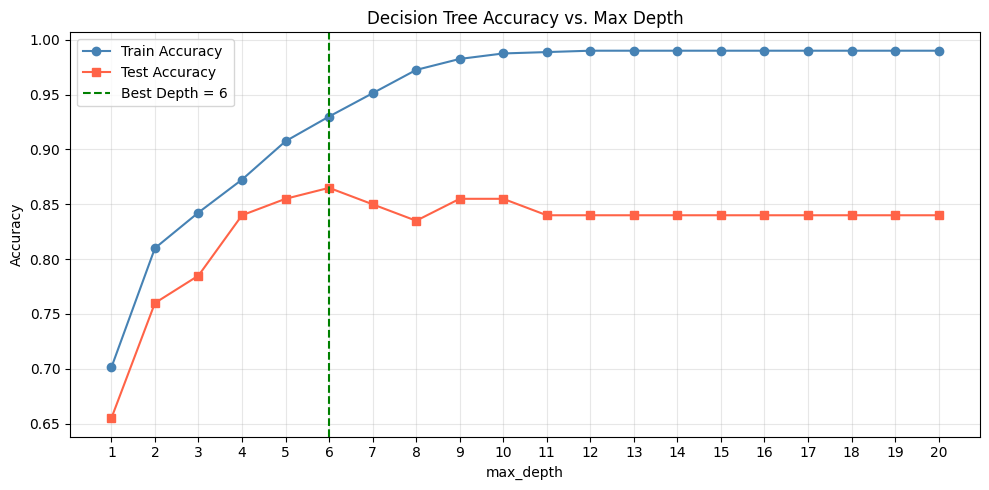

In [26]:
# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_accs,  marker='s', label='Test Accuracy',  color='tomato')
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.legend()
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()